# REAL MADRID INTERNSHIP TEST NOTEBOOK

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [141]:
df = pd.read_csv("data_acute_vs_chronic.csv")

In [142]:
df.head()

,player_id,period_id,period_name,activity_id,period_start_time,position_name_en,is_official_match,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth
0,37191,period_1683,BP 2351,activity_1389,2024-12-16T00:00:00Z,Central Back,NaN,1003.372036,0,0.000000,184.0,79.0,1997-06-22
1,37191,period_4407,G 1669,activity_2423,2025-01-01T00:00:00Z,Central Back,NaN,1223.749101,4,4.960388,184.0,79.0,1997-06-22
2,37191,period_883,BP 4893,activity_4655,2025-04-06T00:00:00Z,Central Back,NaN,747.250469,4,0.000000,184.0,79.0,1997-06-22
3,37191,period_1790,G 3164,activity_911,2025-04-03T00:00:00Z,Central Back,NaN,1196.351675,2,0.000000,184.0,79.0,1997-06-22
4,37191,period_2421,BP 0518,activity_3073,2025-05-06T00:00:00Z,Central Back,NaN,322.200458,2,0.000000,184.0,79.0,1997-06-22


In [143]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3903 entries, 0 to 3902
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   player_id                           3903 non-null   int64  
 1   period_id                           3903 non-null   object 
 2   period_name                         2930 non-null   object 
 3   activity_id                         3903 non-null   object 
 4   period_start_time                   3903 non-null   object 
 5   position_name_en                    3884 non-null   object 
 6   is_official_match                   973 non-null    float64
 7   total_distance                      3903 non-null   float64
 8   acc_band7plus_total_effort_count    3903 non-null   int64  
 9   velocity_band6plus7_total_distance  3903 non-null   float64
 10  height                              3884 non-null   float64
 11  weight                              3884 no

# Exploratory Data Analysis

## 1. Replacing Nan values of `is_official_match` with 0 and converting column datatype to Boolean

In [144]:
df['is_official_match'] = df['is_official_match'].fillna(0).astype(bool)

# Changing datatype of player_id to object
df['player_id'] = df['player_id'].astype(str)

In [145]:
df.head()

,player_id,period_id,period_name,activity_id,period_start_time,position_name_en,is_official_match,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth
0,37191,period_1683,BP 2351,activity_1389,2024-12-16T00:00:00Z,Central Back,False,1003.372036,0,0.000000,184.0,79.0,1997-06-22
1,37191,period_4407,G 1669,activity_2423,2025-01-01T00:00:00Z,Central Back,False,1223.749101,4,4.960388,184.0,79.0,1997-06-22
2,37191,period_883,BP 4893,activity_4655,2025-04-06T00:00:00Z,Central Back,False,747.250469,4,0.000000,184.0,79.0,1997-06-22
3,37191,period_1790,G 3164,activity_911,2025-04-03T00:00:00Z,Central Back,False,1196.351675,2,0.000000,184.0,79.0,1997-06-22
4,37191,period_2421,BP 0518,activity_3073,2025-05-06T00:00:00Z,Central Back,False,322.200458,2,0.000000,184.0,79.0,1997-06-22


## 2. Training types are encoded in `period_name` prefixes

In [146]:
df['period_name'].str.split(' ').str[0].value_counts()

period_name
G      1184
TAC     800
BP      684
TEC     262
Name: count, dtype: int64

The letters stand for the following (most likely):
- G (Game Situation)
- TAC (Tactical)
- BP (Ball Possession / physical)
- TEC (Technical)

There are certain missing values in `period_name`.

In [147]:
print("Missing values in period_name when is_official_match is True",df[df['is_official_match']==True].period_name.isna().sum())

print("Missing values in period_name when is_official_match is False",df[df['is_official_match']==False].period_name.isna().sum())

Missing values in period_name when is_official_match is True 973
Missing values in period_name when is_official_match is False 0


So, we can rename the rows in `period_name` with missing values with "MATCH" and also create a `training_type` column

In [148]:
df['period_name'] = df['period_name'].fillna("MATCH")

df['training_type'] = df['period_name'].str.split(' ').str[0]

## 3. Converting `period_start_time` and `date_of_birth` to datetime datatype, then extractiing the date and deleting the time because the time value is same for all the rows.

In [149]:
df['period_start_time'] = pd.to_datetime(df['period_start_time'])
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
df['period_start_date'] = pd.to_datetime(df['period_start_time'].dt.date)
df = df.drop(columns=['period_start_time'])

## 4. Handling missing values in `position_name_en`

In [150]:
df[df['position_name_en'].isna()]

,player_id,period_id,period_name,activity_id,position_name_en,is_official_match,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth,training_type,period_start_date
729,50333,period_2511,BP 4893,activity_4699,NaN,False,688.441948,1,0.000000,NaN,NaN,NaT,BP,2024-07-30
730,50333,period_4143,G 5146,activity_4581,NaN,False,3748.645665,12,1.379351,NaN,NaN,NaT,G,2024-08-01
731,50333,period_2894,TAC 0133,activity_4699,NaN,False,972.654794,2,30.106453,NaN,NaN,NaT,TAC,2024-07-30
732,50333,period_2816,TEC 5341,activity_4581,NaN,False,208.170016,0,0.000000,NaN,NaN,NaT,TEC,2024-08-01
733,50333,period_4067,G 3218,activity_2160,NaN,False,2021.850478,0,30.802694,NaN,NaN,NaT,G,2024-07-29
734,50333,period_4216,G 0184,activity_1230,NaN,False,1519.833319,7,0.000000,NaN,NaN,NaT,G,2024-07-27
735,50333,period_1247,G 0184,activity_1230,NaN,False,1766.106161,5,24.061758,NaN,NaN,NaT,G,2024-07-27
736,50333,period_4016,BP 2269,activity_1230,NaN,False,629.412270,4,0.000000,NaN,NaN,NaT,BP,2024-07-27
737,50333,period_4157,G 1960,activity_4699,NaN,False,1003.310644,2,19.124586,NaN,NaN,NaT,G,2024-07-30
738,50333,period_1957,G 0184,activity_1230,NaN,False,2656.759623,1,0.000000,NaN,NaN,NaT,G,2024-07-27


In [151]:
df[df['position_name_en'].isna()]['player_id'].value_counts()

player_id
50333    19
Name: count, dtype: int64

Only one player with `player_id` = **50333** has missing values. Also, the same rows have missing values in `weight`, `height` and `date_of_birth` columns.

He has attended 19 trainings in total. Let's check how many days of training has the player done.

In [152]:
df_50333 = df[df['player_id'] == '50333']

In [153]:
df_50333.period_start_date.unique()

<DatetimeArray>
['2024-07-30 00:00:00', '2024-08-01 00:00:00', '2024-07-29 00:00:00',
 '2024-07-27 00:00:00', '2024-08-02 00:00:00']
Length: 5, dtype: datetime64[ns]

Player with `player_id` = **50333** has fone only 5 days of training which is not enough to calculate ACWR anyways. So, we can remove all the rows containing his data.

In [154]:
df = df[df['player_id'] != 50333]

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3903 entries, 0 to 3902
Data columns (total 14 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   player_id                           3903 non-null   object        
 1   period_id                           3903 non-null   object        
 2   period_name                         3903 non-null   object        
 3   activity_id                         3903 non-null   object        
 4   position_name_en                    3884 non-null   object        
 5   is_official_match                   3903 non-null   bool          
 6   total_distance                      3903 non-null   float64       
 7   acc_band7plus_total_effort_count    3903 non-null   int64         
 8   velocity_band6plus7_total_distance  3903 non-null   float64       
 9   height                              3884 non-null   float64       
 10  weight                  

There are no more missing values in the dataset. Next we will check for outliers

In [156]:
df.head()

,player_id,period_id,period_name,activity_id,position_name_en,is_official_match,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth,training_type,period_start_date
0,37191,period_1683,BP 2351,activity_1389,Central Back,False,1003.372036,0,0.000000,184.0,79.0,1997-06-22,BP,2024-12-16
1,37191,period_4407,G 1669,activity_2423,Central Back,False,1223.749101,4,4.960388,184.0,79.0,1997-06-22,G,2025-01-01
2,37191,period_883,BP 4893,activity_4655,Central Back,False,747.250469,4,0.000000,184.0,79.0,1997-06-22,BP,2025-04-06
3,37191,period_1790,G 3164,activity_911,Central Back,False,1196.351675,2,0.000000,184.0,79.0,1997-06-22,G,2025-04-03
4,37191,period_2421,BP 0518,activity_3073,Central Back,False,322.200458,2,0.000000,184.0,79.0,1997-06-22,BP,2025-05-06


## 5. Checking for Outliers

In [157]:
df.describe()

,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth,period_start_date
count,3903.000000,3903.000000,3903.000000,3884.000000,3884.000000,3884,3903
mean,1335.858169,4.973098,13.356361,176.972451,75.903193,1998-08-06 12:03:20.205973248,2025-01-10 06:19:38.785549568
min,44.093973,0.000000,0.000000,169.000000,64.000000,1969-01-16 00:00:00,2024-07-16 00:00:00
25%,713.578274,2.000000,0.000000,173.000000,67.000000,1996-07-28 00:00:00,2024-09-27 00:00:00
50%,1170.471234,5.000000,1.281572,177.000000,71.000000,1999-03-09 00:00:00,2025-02-07 00:00:00
75%,1676.564775,7.000000,20.958936,181.000000,79.000000,2002-03-24 00:00:00,2025-04-12 00:00:00
max,32299.892493,27.000000,191.200596,195.000000,200.000000,2007-09-02 00:00:00,2025-06-26 00:00:00
std,1042.696531,3.769709,20.707415,5.486529,19.355849,NaN,NaN


Some peculiar characteristics noticed which are outliers:

- One player covered a distance of 32.3k in a single training period.
- Players having weight as 200.
- Players born in 1969 are taking part in training. They are more than 50 years old.

### 5.1. 32.3k distance covered

In [158]:
df.sort_values(by='total_distance', ascending=False).head()

,player_id,period_id,period_name,activity_id,position_name_en,is_official_match,total_distance,acc_band7plus_total_effort_count,velocity_band6plus7_total_distance,height,weight,date_of_birth,training_type,period_start_date
3784,94884,period_1501,MATCH,activity_3585,Forward,True,32299.892493,15,23.465222,175.0,78.0,1998-07-14,MATCH,2025-02-15
2171,11983,period_3493,MATCH,activity_1612,Central Midfielder,True,11093.472232,4,2.068091,172.0,66.0,1985-11-07,MATCH,2024-12-10
1347,21190,period_2160,MATCH,activity_26,Full Back,True,8163.381856,11,47.841802,173.0,71.0,1991-03-18,MATCH,2025-04-13
2922,93988,period_934,TAC 2764,activity_3073,Central Midfielder,False,7986.864611,2,54.079530,170.0,70.0,2005-05-31,TAC,2025-05-06
1903,48463,period_4655,MATCH,activity_1778,Central Midfielder,True,7831.834147,3,56.349076,181.0,77.0,1998-03-22,MATCH,2024-09-21


We can see that it's only for 1 row in the dataset. It was in a **MATCH** event by player **94884** who is a **Forward**

In [159]:
df_94884 = df[(df['player_id']=='94884') & (df['is_official_match']==True)]

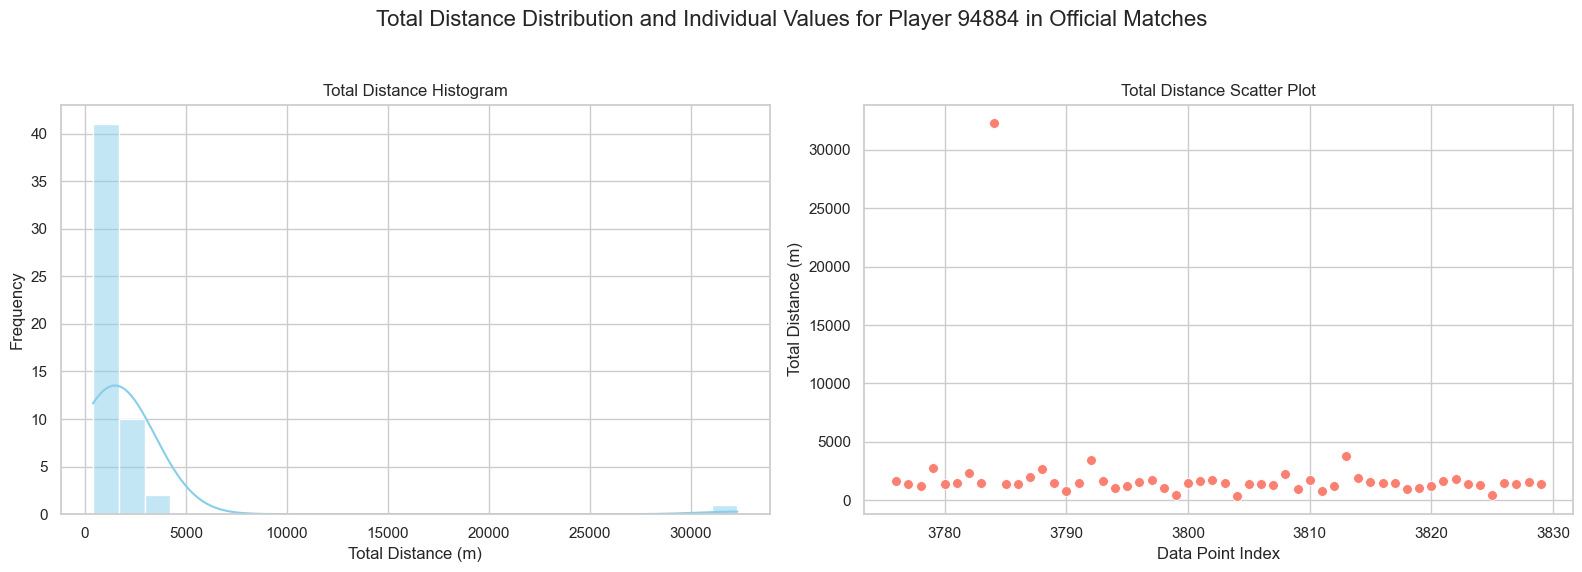

In [160]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Total Distance Distribution and Individual Values for Player 94884 in Official Matches", fontsize=16)

# Histogram for total_distance using Seaborn
sns.histplot(df_94884['total_distance'], bins=25, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title("Total Distance Histogram")
axes[0].set_xlabel("Total Distance (m)")
axes[0].set_ylabel("Frequency")

# Scatter plot for total_distance using Seaborn
sns.scatterplot(x=df_94884.index, y=df_94884['total_distance'], ax=axes[1], color='salmon', s=50)
axes[1].set_title("Total Distance Scatter Plot")
axes[1].set_xlabel("Data Point Index")
axes[1].set_ylabel("Total Distance (m)")

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

Distribution of `total_distance` of the player without the outlier

Mean of total_distance (excluding outlier): 1520.16 m
Median of total_distance (excluding outlier): 1461.14 m
Mode of total_distance (excluding outlier): 393.73 m


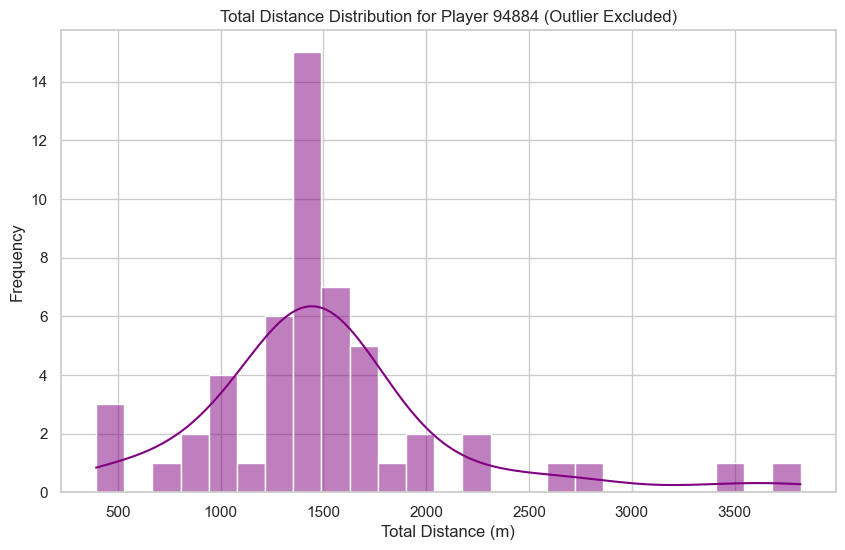

In [161]:
df_94884_filtered = df_94884[df_94884['total_distance'] <= 20000]

# Calculate mean, median, mode for the filtered data
mean_distance = df_94884_filtered['total_distance'].mean()
median_distance = df_94884_filtered['total_distance'].median()
mode_distance = df_94884_filtered['total_distance'].mode()[0] # .mode() can return multiple values, so take the first

print(f"Mean of total_distance (excluding outlier): {mean_distance:.2f} m")
print(f"Median of total_distance (excluding outlier): {median_distance:.2f} m")
print(f"Mode of total_distance (excluding outlier): {mode_distance:.2f} m")

# Plot histogram for the filtered data using Seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df_94884_filtered['total_distance'], bins=25, kde=True, color='purple')
plt.title("Total Distance Distribution for Player 94884 (Outlier Excluded)")
plt.xlabel("Total Distance (m)")
plt.ylabel("Frequency")
plt.show()

The **median** value has a very high frequency so we will replace the distance with the median value.

In [162]:
df.loc[(df['player_id'] == '94884') & (df['total_distance'] >= 20000), 'total_distance'] = median_distance

# Verify the change
print("Value after replacement:")
print(df[(df['player_id'] == '94884') & (df['period_start_date'] == '2025-02-15')][['total_distance']])

Value after replacement:
      total_distance
3784     1461.144621


### 5.2. Players having `weight` = 200

In [163]:
print("Number of entries with weight as 200:", len(df[df['weight']==200]))
print("Height value of the corresponding rows:",df[df['weight']==200].height.unique())
df[df['weight']==200].player_id.value_counts()

Number of entries with weight as 200: 82
Height value of the corresponding rows: [180.]


player_id
15795    30
42978    21
93116    16
86086    10
89091     3
60819     2
Name: count, dtype: int64

There are 6 players with weight as 200. The height value for all of them is 180. There are a total of 82 entries. Checking if those players have a different weight in any other entry.

In [164]:
# List of player IDs to check
target_players = ['15795', '42978', '93116', '86086', '89091', '60819']

# Option 1: Get all unique weight values across these players
unique_weights_all = df[df['player_id'].isin(target_players)]['weight'].unique()
print("Unique weights for all selected players:", unique_weights_all)
# Option 1: Get all unique height values across these players
unique_heights_all = df[df['player_id'].isin(target_players)]['height'].unique()
print("Unique height for all selected players:", unique_heights_all)

# Option 2: See unique weights grouped by each player
unique_weights_per_player = df[df['player_id'].isin(target_players)].groupby('player_id')['weight'].unique()
print("\nUnique weights per player:")
print(unique_weights_per_player)

# Option 2: See unique heights grouped by each player
unique_heights_per_player = df[df['player_id'].isin(target_players)].groupby('player_id')['height'].unique()
print("\nUnique heights per player:")
print(unique_heights_per_player)

Unique weights for all selected players: [200.]
Unique height for all selected players: [180.]

Unique weights per player:
player_id
15795    [200.0]
42978    [200.0]
60819    [200.0]
86086    [200.0]
89091    [200.0]
93116    [200.0]
Name: weight, dtype: object

Unique heights per player:
player_id
15795    [180.0]
42978    [180.0]
60819    [180.0]
86086    [180.0]
89091    [180.0]
93116    [180.0]
Name: height, dtype: object


In [165]:
# ---- Weight cleaning ----
df.loc[(df['weight'] > 120) | (df['weight'] < 50), 'weight'] = np.nan

# Fill with player median
df['weight'] = df.groupby('player_id')['weight'].transform(lambda x: x.fillna(x.median()))

# Fallback: global median
df['weight'] = df['weight'].fillna(df['weight'].median())


# ---- Age feature ----
df['age'] = (df['period_start_date'] - df['date_of_birth']).dt.days / 365

# Remove unrealistic ages
df = df[(df['age'] >= 16) & (df['age'] <= 45)]

/opt/anaconda3/envs/pedri/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/pedri/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/pedri/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/pedri/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/pedri/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/opt/anaconda3/envs/pedri/lib/python3.11/site-packages/numpy/lib/_nanf

## Workload Formula

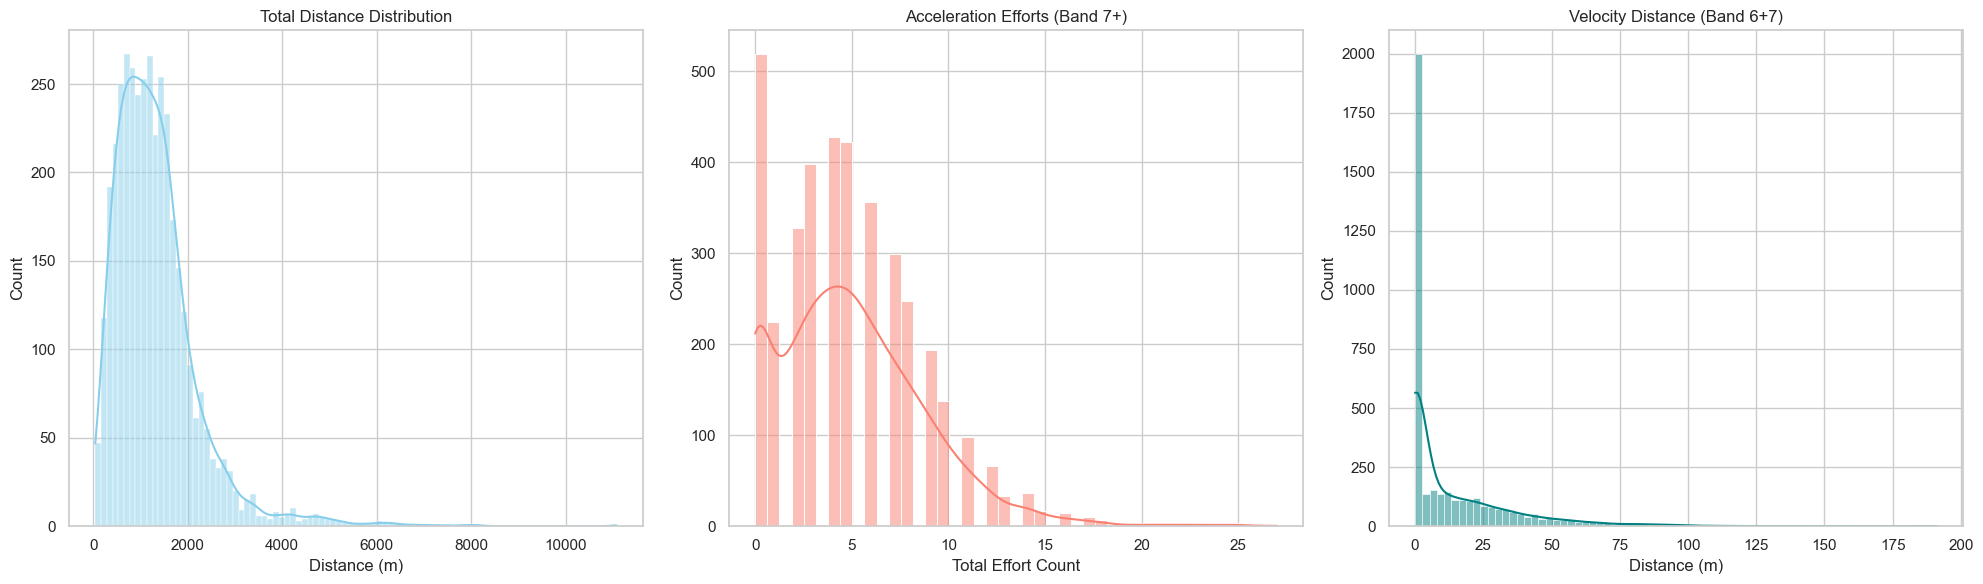

In [166]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual theme
sns.set_theme(style="whitegrid")

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Histogram 1: total_distance
sns.histplot(df['total_distance'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Total Distance Distribution')
axes[0].set_xlabel('Distance (m)')

# Histogram 2: acc_band7plus_total_effort_count
sns.histplot(df['acc_band7plus_total_effort_count'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Acceleration Efforts (Band 7+)')
axes[1].set_xlabel('Total Effort Count')

# Histogram 3: velocity_band6plus7_total_distance
sns.histplot(df['velocity_band6plus7_total_distance'], kde=True, ax=axes[2], color='teal')
axes[2].set_title('Velocity Distance (Band 6+7)')
axes[2].set_xlabel('Distance (m)')

# Clean up layout
plt.tight_layout()
plt.show()


### Normalizing Workload component

In [167]:
features_to_normalize = [
    'total_distance',
    'velocity_band6plus7_total_distance',
    'acc_band7plus_total_effort_count'
]

for col in features_to_normalize:
    df[f'{col}_norm'] = (df[col] - df[col].mean()) / df[col].std()

### Create workload

In [168]:
df['workload'] = (
    df['total_distance_norm'] +
    df['velocity_band6plus7_total_distance_norm'] +
    df['acc_band7plus_total_effort_count_norm']
)

### Daily Aggregation

In [169]:
daily = df.groupby(['player_id', 'period_start_date']).agg({
    'workload': 'sum',
    'is_official_match': 'max',
    'position_name_en': 'first',
    'age': 'first'
}).reset_index()

daily = daily.sort_values(['player_id', 'period_start_date'])

### EWMA ACWR

In [170]:
def compute_ewma(series, span):
    return series.ewm(span=span, adjust=False).mean()

In [171]:
daily['acute_load'] = daily.groupby('player_id')['workload'].transform(lambda x: compute_ewma(x, span=7))
daily['chronic_load'] = daily.groupby('player_id')['workload'].transform(lambda x: compute_ewma(x, span=28))

In [172]:
daily['ACWR'] = daily['acute_load'] / daily['chronic_load']

# Clean infinities
daily = daily.replace([np.inf, -np.inf], np.nan)
daily = daily.dropna(subset=['ACWR'])

### Feature Engineering

In [173]:
daily['acwr_lag1'] = daily.groupby('player_id')['ACWR'].shift(1)
daily['acwr_lag3'] = daily.groupby('player_id')['ACWR'].shift(3)

In [174]:
daily['load_7d'] = daily.groupby('player_id')['workload'].transform(lambda x: x.rolling(7).mean())
daily['load_28d'] = daily.groupby('player_id')['workload'].transform(lambda x: x.rolling(28).mean())

In [175]:
daily['std_7d'] = daily.groupby('player_id')['workload'].transform(lambda x: x.rolling(7).std())

In [176]:
daily['monotony'] = daily['load_7d'] / daily['std_7d']

In [177]:
daily['load_trend'] = daily.groupby('player_id')['load_7d'].diff()

In [178]:
daily['is_match'] = daily['is_official_match'].astype(int)

In [180]:
daily['days_since_match'] = daily.groupby('player_id')['is_match'].transform(
    lambda x: x.groupby((x == 1).cumsum()).cumcount()
)

In [181]:
daily['avg_load_player'] = daily.groupby('player_id')['workload'].transform('mean')
daily['relative_load'] = daily['workload'] / daily['avg_load_player']

In [182]:
daily['target_ACWR'] = daily.groupby('player_id')['ACWR'].shift(-1)

In [183]:
daily = daily.dropna()

In [184]:
features = [
    'workload',
    'acute_load',
    'chronic_load',
    'acwr_lag1',
    'acwr_lag3',
    'load_7d',
    'load_28d',
    'std_7d',
    'monotony',
    'load_trend',
    'is_match',
    'days_since_match',
    'relative_load',
    'age'
]

X = daily[features]
y = daily['target_ACWR']

In [185]:
split_date = daily['period_start_date'].quantile(0.8)

X_train = X[daily['period_start_date'] <= split_date]
X_test = X[daily['period_start_date'] > split_date]

y_train = y[daily['period_start_date'] <= split_date]
y_test = y[daily['period_start_date'] > split_date]

In [186]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

MAE: 8.288873400607415
R2: -10.687810697757765


In [ ]:
for day in range(15):
    # 1. assign expected workload based on training type
    # 2. update rolling features
    # 3. predict ACWR
    # 4. append result